# Online Course User Engagement Data Preparation

![](https://storage.googleapis.com/kaggle-datasets-images/4201617/7251732/bbf27b0500d541fe4ab8df8091147d81/dataset-cover.png)

Dataset Link: https://www.kaggle.com/datasets/thedevastator/online-course-user-engagement-data/data

The dataset above needs some love and care before any meaningful analysis can be done. The purpose of this notebook is to prepare the above dataset for analysis by taking the following steps.


> Data Collection & Understanding
> * Collect Data
> * Discover & Profile
> 
> Data Cleaning & Validation
> * Clean Data
> * Validate Data
> 
> Data Transformation & Enrichment
> * Transform Data
> * Enrich Data
> 
> Data Structuring & Organization
> * Structure Data
> * Format Data

# Data Collection & Understanding

*Gather and get to know the data.*

### Collect Data

In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

# import data drop, duplicate rows

def og_exists(df_name):
    return df_name in locals() or df_name in globals()

if og_exists('og_dataset'):
    print('Already exists')
else: 
    og_dataset = pd.read_csv('/kaggle/input/online-course-user-engagement-data/Courses.csv')

dataset = og_dataset
dataset = dataset.drop_duplicates()

### Discover & Profile

From [Source](https://www.kaggle.com/datasets/thedevastator/online-course-user-engagement-data/data)

> This dataset offers a comprehensive and in-depth record of user engagement and enrolment in online courses. Compiled by JIFAN LI, the dataset encompasses intricate details concerning the way users are interacting with different virtual courses and platforms. It incorporates demographic details of users along with their specific activity metrics and performance indicators.

#### Columns

* **Random** 	A unique numeric identifier assigned arbitrarily for each user. (Numeric)
* **registered** 	Indicates whether the user has registered for the course. (Boolean)
* **viewed** 	Indicates whether the course material was viewed by the student. (Boolean)
* **explored** 	Indicates whether learners explored beyond what was required for their particular online program. (Boolean)
* **certified** 	Indicates if users have successfully completed assignments/tests/exams to earn certificates of completion/accomplishment/achievement. (Boolean)
* **final_cc_cname_DI** 	Indicates users' geographical location. (String)
* **LoE_DI** 	Indicates students' pre-existing educational achievement level before enrolling in an online course. (String)
* **YoB** 	Records learner's birth year. (Numeric)
* **gender** 	Indicates students' sex (male or female). (String)
* **grade** 	Numeric score attained after completion. (Numeric)
* **start_time_DI** 	Date when the course was started by the student. (Date)
* **last_event_DI** 	Date of the last activity performed by the student in the course. (Date)
* **nevents** 	Number of interactions/events a user has had with the online platform. (Numeric)
* **ndays_act** 	Number of active days within the course. (Numeric)
* **nchapters** 	Number of chapters interacted within the course. (Numeric)
* **nforum_posts** 	Number of posts made in course forums. (Numeric)
* **roles** 	Role of the learner within the course (e.g., student, instructor). (String)
* **incomplete_flag** 	Indicates if the course was left incomplete by the student. (Boolean)

# Data Cleaning & Validation

*Fix issues with the data.*

### Clean Data


In [2]:
# force pandas to show all columns
pd.set_option('display.max_columns', None)

display(
    dataset.info(),
    dataset.isnull().sum()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              641138 non-null  int64  
 1   Random             641138 non-null  int64  
 2   course_id          641138 non-null  object 
 3   userid_DI          641138 non-null  object 
 4   registered         641138 non-null  int64  
 5   viewed             641138 non-null  int64  
 6   explored           641138 non-null  int64  
 7   certified          641138 non-null  int64  
 8   final_cc_cname_DI  641138 non-null  object 
 9   LoE_DI             535130 non-null  object 
 10  YoB                544533 non-null  float64
 11  gender             554332 non-null  object 
 12  grade              592766 non-null  object 
 13  start_time_DI      641138 non-null  object 
 14  last_event_DI      462184 non-null  object 
 15  nevents            441987 non-null  float64
 16  nd

None

index                     0
Random                    0
course_id                 0
userid_DI                 0
registered                0
viewed                    0
explored                  0
certified                 0
final_cc_cname_DI         0
LoE_DI               106008
YoB                   96605
gender                86806
grade                 48372
start_time_DI             0
last_event_DI        178954
nevents              199151
ndays_act            162743
nplay_video          457530
nchapters            258753
nforum_posts              0
roles                641138
incomplete_flag      540977
dtype: int64

Upon initial examination there are a few potential issues that need resolving:

1. Possiblity of irrelevant/non-useful columns
1. Existence of columns not mentioned in the source page.
    * course_id
    * userid_DI
    * nplay_video
1. Wrong data types
1. Null values in the data

Let's get cleaning.
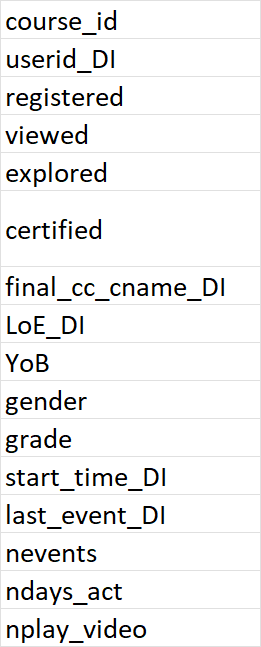
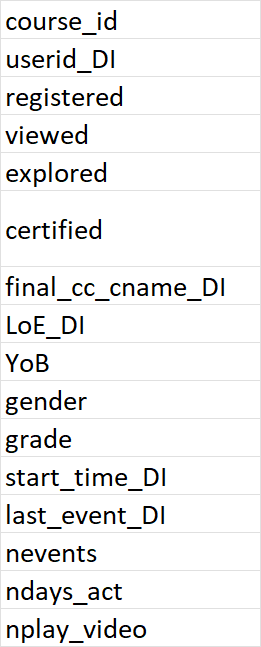
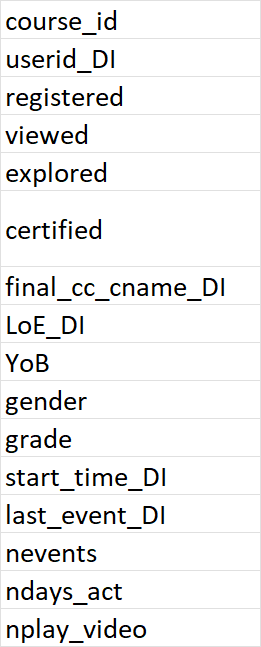

In [3]:
# drop useless columns
dataset.drop(columns=['index','Random', 'roles'], inplace=True, errors='ignore')

# fix datetimes
dataset['start_time_DI'] = pd.to_datetime(dataset['start_time_DI'])
dataset['last_event_DI'] = pd.to_datetime(dataset['last_event_DI'])

# create grade categories to keep track of original 'grade' column
def categorize_grade(grade):
    if pd.isnull(grade):
        return 'null-'
    elif grade == ' ':
        return 'empty'
    elif grade == '0':
        return 'zero'
    else:
        return 'non-zero'

dataset['grade_cat'] = dataset['grade'].apply(categorize_grade)

# replace empty strings with nulls, fix type
dataset['grade'] = dataset['grade'].replace(' ', np.nan, regex=True)
dataset['grade'] = dataset['grade'].astype('float64')

# replace nulls with '0', change type to int
cols = ['nevents', 'ndays_act', 'nplay_video', 'nchapters', 'incomplete_flag']
for col in cols:
    dataset[col] = dataset[col].fillna(0).astype('int64')

# convert relevant columns to bool type
bool_cols = ['registered', 'viewed', 'explored', 'certified', 'incomplete_flag']
for col in bool_cols:
    dataset[col] = dataset[col].astype(bool)

# replace grades exceeding 100 with 100
dataset['grade'] = dataset['grade'].replace(1.01, 1.00)

# impute nulls for columns where possible
dataset['final_cc_cname_DI'] = dataset['final_cc_cname_DI'].replace('Unknown/Other', np.nan, regex=True)
dim_cols = ['final_cc_cname_DI', 'LoE_DI', 'YoB', 'gender']
for col in dim_cols:
    dataset[col] = dataset.groupby('userid_DI')[col].ffill()
    dataset[col] = dataset.groupby('userid_DI')[col].bfill()

# replace nulls in cat columns
cols = ['final_cc_cname_DI', 'LoE_DI', 'gender']
for col in cols:
    dataset[col] = dataset[col].fillna('(unknown)')

### Validate Data
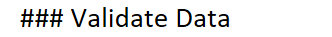
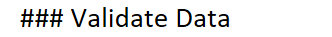

Based on our current understanding of the data, we can do some logical checks.
* If `certified` is true, `viewed` should be true.
* If `certified` is true, `grade` should be > 0.
* If `certified` is true, `incomplete_flag` should be false.
* `start_time_DI` should always be <= `last_event_DI`.
* `ndays_act` should be consistent with the duration between `start_time_DI` and `last_event_DI`.
* If `certified` is true, there should be at least some engagement metrics > 0.
    * For example, `nevents`, `ndays_act`, `nplay_video`, `nchapters`, `nforum_posts`
* If engagement metrics are zero (either `nevents` or others), `certified` should be false.
* Assuming `nevents` is an all-encompassing measure of engagement, when `nevents` = 0, other engagement metrics should also be 0.

We'll start the checklist from the top.

Validate:
1. If `certified` is true, `viewed` should be true.
1. If `certified` is true, `grade` should be > 0.
1. If `certified` is true, `incomplete_flag` should be false.

In [4]:
certified = dataset[dataset.certified == True]

display(
    certified.viewed.value_counts(),
    certified.grade.value_counts(),
    certified.incomplete_flag.value_counts()
)

viewed
True    17687
Name: count, dtype: int64

grade
1.00    2016
0.89     586
0.91     575
0.93     551
0.88     545
0.90     541
0.96     535
0.87     507
0.97     504
0.99     502
0.92     502
0.94     497
0.86     488
0.95     466
0.85     434
0.98     423
0.82     403
0.80     396
0.83     390
0.84     382
0.81     367
0.77     305
0.75     294
0.79     289
0.74     289
0.76     283
0.78     279
0.73     278
0.70     273
0.71     272
0.67     271
0.68     271
0.72     260
0.64     259
0.62     256
0.69     251
0.66     250
0.61     238
0.63     236
0.65     233
0.60     218
0.59     107
0.56     105
0.57     100
0.55      93
0.58      93
0.53      68
0.50      56
0.52      55
0.51      48
0.54      46
0.00       1
Name: count, dtype: int64

incomplete_flag
False    17675
True        12
Name: count, dtype: int64

Validation results:

We successfully validated the first condition. The second and third condition have 13 rows we need to drop.

Validate:

* `start_time_DI` should always be <= `last_event_DI`.

In [5]:
late_start = dataset[dataset.start_time_DI > dataset.last_event_DI]
late_start

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,grade_cat
244,HarvardX/CS50x/2012,MHxPC130464231,True,True,False,False,India,(unknown),NaN,(unknown),0.0,2013-08-18,2013-03-16,1,1,0,1,0,False,zero
261,HarvardX/CS50x/2012,MHxPC130216109,True,True,False,False,Canada,(unknown),NaN,(unknown),0.0,2013-08-17,2013-03-15,1,1,0,1,0,False,zero
775,HarvardX/CS50x/2012,MHxPC130591769,True,True,True,False,Ukraine,(unknown),NaN,(unknown),0.0,2013-08-27,2013-05-24,51,3,0,8,0,False,zero
930,HarvardX/ER22x/2013_Spring,MHxPC130019081,True,True,False,False,United Kingdom,(unknown),NaN,(unknown),NaN,2013-07-30,2013-04-27,862,16,0,14,2,False,null-
1091,HarvardX/CS50x/2012,MHxPC130295771,True,True,False,False,Other Europe,(unknown),NaN,(unknown),0.0,2013-07-19,2013-04-07,1,1,0,2,0,False,zero
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631895,MITx/6.002x/2013_Spring,MHxPC130305552,True,False,False,False,India,Secondary,1994.0,m,NaN,2013-07-31,2013-07-26,3,1,0,0,0,False,null-
631907,MITx/6.002x/2013_Spring,MHxPC130502670,True,True,False,False,United States,Master's,1982.0,m,NaN,2013-07-29,2013-07-26,10,1,2,1,0,False,null-
632350,MITx/6.002x/2013_Spring,MHxPC130399133,True,False,False,False,India,Secondary,1995.0,m,NaN,2013-08-27,2013-08-15,2,2,0,0,0,False,null-
632351,MITx/6.00x/2013_Spring,MHxPC130399133,True,False,False,False,India,Secondary,1995.0,m,NaN,2013-08-27,2013-08-15,7,1,0,0,0,False,null-


Validation Results: drop these rows

Validate:

* `ndays_act` should be consistent with the duration between `start_time_DI` and `last_event_DI`.

In [6]:
dataset[(
    dataset.ndays_act > (dataset.last_event_DI - dataset.start_time_DI).dt.days+2
)]

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,grade_cat
244,HarvardX/CS50x/2012,MHxPC130464231,True,True,False,False,India,(unknown),NaN,(unknown),0.0,2013-08-18,2013-03-16,1,1,0,1,0,False,zero
247,HarvardX/CS50x/2012,MHxPC130398182,True,True,False,False,Egypt,(unknown),NaN,(unknown),0.0,2013-05-31,2013-06-09,116,17,0,5,0,False,zero
261,HarvardX/CS50x/2012,MHxPC130216109,True,True,False,False,Canada,(unknown),NaN,(unknown),0.0,2013-08-17,2013-03-15,1,1,0,1,0,False,zero
689,HarvardX/CB22x/2013_Spring,MHxPC130318951,True,True,False,False,United States,(unknown),NaN,(unknown),0.0,2013-04-07,2013-04-07,84,4,0,3,0,False,zero
725,HarvardX/CS50x/2012,MHxPC130051807,True,True,False,False,United Kingdom,(unknown),NaN,(unknown),0.0,2013-03-10,2013-03-10,17,5,0,1,0,False,zero
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633156,MITx/6.00x/2013_Spring,MHxPC130340112,True,True,False,False,Other Africa,Bachelor's,1983.0,m,NaN,2013-08-29,2013-08-30,48,4,6,3,0,False,null-
633311,MITx/6.00x/2013_Spring,MHxPC130104228,True,True,True,False,Other South Asia,Less than Secondary,1996.0,m,NaN,2013-08-06,2013-08-09,355,6,58,10,0,False,null-
634544,MITx/8.MReV/2013_Summer,MHxPC130386187,True,True,False,False,India,Secondary,1994.0,m,0.0,2013-08-17,2013-08-17,258,4,0,2,1,False,zero
635024,MITx/6.002x/2013_Spring,MHxPC130444849,True,False,False,False,United States,Bachelor's,1990.0,m,NaN,2013-08-19,2013-08-10,5,1,0,0,0,False,null-


Validation Results: drop these rows

Validate:

* If engagement metrics are zero (either `nevents` or others), `certified` should be false.

In [7]:
no_events = dataset[dataset.nevents == 0]
no_events.certified.value_counts()

certified
False    199139
True         12
Name: count, dtype: int64

Validation Results: drop these rows

Validate:

* Assuming `nevents` is an all-encompassing measure of engagement, when `nevents` = 0, other engagement metrics should also be 0.

In [8]:
no_events[(
    (no_events.ndays_act > 0) |
    (no_events.nplay_video > 0) |
    (no_events.nchapters > 0) |
    (no_events.nforum_posts > 0)
)]

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag,grade_cat
0,HarvardX/CB22x/2013_Spring,MHxPC130442623,True,False,False,False,United States,(unknown),NaN,(unknown),0.0,2012-12-19,2013-11-17,0,9,0,0,0,True,zero
1,HarvardX/CS50x/2012,MHxPC130442623,True,True,False,False,United States,(unknown),NaN,(unknown),0.0,2012-10-15,NaT,0,9,0,1,0,True,zero
2,HarvardX/CB22x/2013_Spring,MHxPC130275857,True,False,False,False,United States,(unknown),NaN,(unknown),0.0,2013-02-08,2013-11-17,0,16,0,0,0,True,zero
3,HarvardX/CS50x/2012,MHxPC130275857,True,False,False,False,United States,(unknown),NaN,(unknown),0.0,2012-09-17,NaT,0,16,0,0,0,True,zero
4,HarvardX/ER22x/2013_Spring,MHxPC130275857,True,False,False,False,United States,(unknown),NaN,(unknown),0.0,2012-12-19,NaT,0,16,0,0,0,True,zero
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641101,MITx/6.00x/2013_Spring,MHxPC130298117,True,False,False,False,Russian Federation,Less than Secondary,1997.0,m,NaN,2013-09-07,NaT,0,0,0,1,0,True,null-
641106,MITx/6.002x/2013_Spring,MHxPC130347356,True,False,False,False,India,Secondary,1994.0,m,NaN,2013-09-07,NaT,0,1,0,0,0,True,null-
641109,MITx/6.00x/2013_Spring,MHxPC130493130,True,False,False,False,United Kingdom,Master's,1977.0,m,NaN,2013-09-07,NaT,0,0,0,2,0,True,null-
641121,MITx/6.00x/2013_Spring,MHxPC130282999,True,False,False,False,Other Europe,Master's,1979.0,m,NaN,2013-09-07,NaT,0,0,0,7,0,True,null-


Validation Results:

There are too many rows here, our assumption was incorrect. Apparently `nevents` is not all-ecompassing of the other engagement metrics. 

#### Data Validation Summary


Here are the conditions that result in rows that need to be dropped:
* If `certified` is true, `grade` should be > 0.
* If `certified` is true, `incomplete_flag` should be false.
* `start_time_DI` should always be <= `last_event_DI`.
* `ndays_act` should be consistent with the duration between `start_time_DI` and `last_event_DI`.
* If engagement metrics are zero (either `nevents` or others), `certified` should be false.

Let's drop 'em.

In [9]:
# eliminate some low quality data

display(len(dataset))

condition1 = ((dataset.certified == 1) & (dataset.grade == 0))
condition2 = ((dataset.certified == True) & (dataset.incomplete_flag == True))
condition3 = (dataset.last_event_DI < dataset.start_time_DI)
condition4 = (dataset.ndays_act > (dataset.last_event_DI - dataset.start_time_DI).dt.days+2)
condition5 = ((dataset.certified == 1) & (dataset.nevents == 0))
condition6 = (dataset.nevents > 150000)

dataset = dataset[(
    ~condition1 &
    ~condition2 &
    ~condition3 &
    ~condition4 &
    ~condition5 &
    ~condition6
)]

display(len(dataset))

641138

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


637567

# Data Dictionary (Cleaned Data)

| Column Name         | Data Type      | Description                                                          | Examples of Values                               |
| :------------------ | :------------- | :------------------------------------------------------------------- | :----------------------------------------------- |
| `course_id`         | object         | Categorical identifier for the specific online course.               | `HarvardX/CS50x/2012`, `MITx/6.00x/2013_Spring`    |
| `userid_DI`         | object         | Unique (likely de-identified) identifier for a user account.           | `MHxPC130200926`, `MHxPC130126780`                 |
| `registered`        | bool           | Indicates if the user registered (always True in this dataset).      | `True`                                           |
| `viewed`            | bool           | Indicates if course material was viewed by the user.                 | `True`, `False`                                  |
| `explored`          | bool           | Indicates if the user explored beyond required material.              | `True`, `False`                                  |
| `certified`         | bool           | Indicates if the user earned a certificate.                          | `True`, `False`                                  |
| `final_cc_cname_DI` | object         | User's inferred geographic location (Country Name).                  | `United States`, `India`, `(Unknown)`, `Other Europe` |
| `LoE_DI`            | object         | User's Level of Education prior to the course.                       | `Bachelor's`, `Secondary`, `Master's`, `(Unknown)` |
| `YoB`               | float64        | User's Year of Birth.                                                | `1988.0`, `1991.0`, `1975.0`, `NaN`              |
| `gender`            | object         | User's gender.                                                       | `m`, `f`, `o`, `(Unknown)`                     |
| `grade`             | float64        | Numeric score (0.0-1.0) attained. Null if not graded.              | `0.0`, `0.75`, `1.0`, `NaN`                      |
| `start_time_DI`     | datetime64[ns] | Recorded timestamp, potentially enrollment or activation date.         | `2012-10-01 00:00:00`, `2013-01-09 00:00:00`     |
| `last_event_DI`     | datetime64[ns] | Timestamp of the last recorded interaction event. Null if inactive. | `2013-03-17 00:00:00`, `2012-12-24 00:00:00`, `NaT` |
| `nevents`           | int64          | Total count of recorded interaction events.                          | `0`, `4`, `66`, `1000`, `61376`                   |
| `ndays_act`         | int64          | Number of distinct calendar days with recorded activity.             | `0`, `1`, `3`, `15`, `205`                       |
| `nplay_video`       | int64          | Count of video play events.                                          | `0`, `2`, `50`, `500`, `34596`                   |
| `nchapters`         | int64          | Number of distinct course chapters interacted with.                  | `0`, `1`, `2`, `10`, `48`                        |
| `nforum_posts`      | int64          | Number of posts made by the user in course forums.                   | `0`, `1`, `5`, `20`                              |
| `incomplete_flag`   | bool           | Flag indicating specific inactivity or incompletion status.         | `True`, `False`                                  |
| `grade_cat`         | object         | Categorization based on original grade value.                        | `non-zero`, `null-`, `zero`, `empty`              |

# Data Transformation & Enrichment

*Modify or add to data to fit analysis needs.*

### Transform Data

We already added the `grade_cat` column, categorizing the original grade. This may be useful in further analysis. Additional transformations will depend on the type of analysis being done with this data.

### Enrich Data

There isn't anything to add currently without knowing what kinds of analysis this dataset will be used for. This step can be done depending on what further analysis requires. 

# Data Structuring & Organization

*Ensure data is in a suitable structure and format.*

### Structure Data

We'll keep the data as a flat table for now. There is potential for data modeling further down the line.

### Format Data

It's time to export the data in an appropriate format.

In [10]:
dataset.to_csv('OCUE_cleaned.csv', index=False)
print('Exported as CSV file')

Exported as CSV file


# Summary: Data Quirks & Analysis Cautions

Based on our analysis, here are key quirks and points of caution to remember when working with this dataset:

1.  **`start_time_DI` Unreliability:** This column often occurs *after* the user's first actual activity was recorded (`last_event_DI`). Do not use `start_time_DI` to calculate accurate engagement durations (e.g., `last_event_DI - start_time_DI`). The resulting duration may be artificially short or negative.
2.  **`nevents` Incompleteness/Inconsistency:** The `nevents` count may not capture all interaction types comprehensively. We found instances where `nevents=0` despite positive `nplay_video` or `nchapters`. Treat `nevents` as a *partial* measure of engagement, potentially missing certain activity types due to logging inconsistencies.
3.  **Engagement Metric Outliers & Skew:** `nevents`, `nplay_video`, and `ndays_act` contain extreme maximum values and are highly positively skewed. Be mindful of their influence on means and certain statistical models. Consider using medians, transformations (e.g., log), or robust methods for analysis.
4.  **Implausible `YoB` Values:** The maximum Year of Birth (e.g., 2013) is likely erroneous given the course timeframe. These should be filtered, capped, or treated as NaN before calculating Age. Remember `YoB` also has remaining `NaN` values.
5.  **`grade` Interpretation:** `grade = NaN` (null) likely represents users who dropped out *before* grading occurred (mixed engagement levels). `grade = 0` represents users who reached the grading stage but performed minimally/failed (typically very low engagement). Analyze these segments separately. Also handle remaining `NaN`s appropriately. Use `grade_cat` column to help with this.
6.  **`incomplete_flag` Ambiguity:** If `NaN` values in the original `incomplete_flag` were converted to `False` during cleaning, be aware that `incomplete_flag = False` may include some users who *should* have been flagged as incomplete (due to `nevents=0`) but weren't processed correctly before the `NaN` conversion. Cross-reference with `nevents` when interpreting inactivity.
7.  **Location (`final_cc_cname_DI`) Variability:** A single `userid_DI` can be associated with multiple countries across different course enrollments (due to moves, VPNs, travel, etc.). Interpret this field as the location associated with *that specific enrollment record*, not necessarily a fixed user attribute. Also note the "(Unknown)" category requires handling.
8.  **Remaining Missing Values:** Ensure strategies are in place to handle the remaining `NaN` values in `YoB`, `grade`, and `last_event_DI` depending on the analysis.


# Bonus: EDA

In [11]:
display(Markdown('#### **Funnel Table**'))

dataset.groupby('course_id')[[
    'registered', 
    'viewed', 
    'explored', 
    'certified'
]].sum().sort_values(by='registered', ascending=False).reset_index()

#### **Funnel Table**

,course_id,registered,viewed,explored,certified
0,HarvardX/CS50x/2012,169034,105599,10911,1286
1,MITx/6.00x/2012_Fall,66573,41316,4177,2471
2,HarvardX/ER22x/2013_Spring,57187,32008,3519,2340
3,MITx/6.00x/2013_Spring,57050,53935,2659,1252
4,HarvardX/PH207x/2012_Fall,41210,24056,4303,1839
5,MITx/6.002x/2012_Fall,40400,25688,2991,1747
6,HarvardX/PH278x/2013_Spring,39502,14969,1188,708
7,MITx/8.02x/2013_Spring,30759,20574,1787,821
8,HarvardX/CB22x/2013_Spring,29884,16227,547,384
9,MITx/14.73x/2013_Spring,27764,16314,2931,2084


In [12]:
engage_metrics = ['nevents', 'ndays_act', 'nplay_video', 'nchapters', 'nforum_posts']

for metric in engage_metrics:
    text = Markdown('<br>**Courses by median of {}, descending**'.format(metric))
    text2 = Markdown('<br>**Courses by mean of {}, descending**'.format(metric))
    medians = dataset.groupby('course_id')[metric].median().sort_values(ascending=False)
    means = dataset.groupby('course_id')[metric].mean().sort_values(ascending=False)
    display(text, medians, text2, means)

<br>**Courses by median of nevents, descending**

course_id
MITx/2.01x/2013_Spring         31.0
MITx/8.MReV/2013_Summer        28.0
MITx/6.00x/2012_Fall           26.0
MITx/8.02x/2013_Spring         25.0
MITx/7.00x/2013_Spring         20.0
MITx/6.002x/2012_Fall          19.0
HarvardX/PH207x/2012_Fall      18.0
MITx/6.00x/2013_Spring         18.0
MITx/14.73x/2013_Spring        12.0
MITx/3.091x/2013_Spring        12.0
HarvardX/CB22x/2013_Spring     10.0
HarvardX/ER22x/2013_Spring      8.0
MITx/3.091x/2012_Fall           7.0
MITx/6.002x/2013_Spring         6.0
HarvardX/PH278x/2013_Spring     2.0
HarvardX/CS50x/2012             0.0
Name: nevents, dtype: float64

<br>**Courses by mean of nevents, descending**

course_id
MITx/6.00x/2012_Fall           606.137368
HarvardX/PH207x/2012_Fall      596.583111
MITx/8.02x/2013_Spring         533.077343
MITx/3.091x/2012_Fall          510.455449
MITx/14.73x/2013_Spring        509.880997
MITx/2.01x/2013_Spring         504.175544
MITx/7.00x/2013_Spring         501.714013
MITx/8.MReV/2013_Summer        488.450329
MITx/6.002x/2012_Fall          460.320272
MITx/6.00x/2013_Spring         435.132743
MITx/3.091x/2013_Spring        319.102754
MITx/6.002x/2013_Spring        295.688501
HarvardX/ER22x/2013_Spring     126.547799
HarvardX/PH278x/2013_Spring    111.280112
HarvardX/CB22x/2013_Spring     104.367789
HarvardX/CS50x/2012             11.452974
Name: nevents, dtype: float64

<br>**Courses by median of ndays_act, descending**

...

course_id
MITx/8.MReV/2013_Summer        3.794311
HarvardX/ER22x/2013_Spring     3.621505
MITx/8.02x/2013_Spring         2.677330
HarvardX/PH207x/2012_Fall      2.540500
MITx/7.00x/2013_Spring         2.455270
MITx/6.00x/2013_Spring         2.410535
MITx/6.002x/2012_Fall          2.406460
MITx/6.00x/2012_Fall           2.370601
MITx/2.01x/2013_Spring         2.335516
MITx/6.002x/2013_Spring        1.971582
MITx/3.091x/2013_Spring        1.939799
MITx/14.73x/2013_Spring        1.907974
MITx/3.091x/2012_Fall          1.758353
HarvardX/CB22x/2013_Spring     1.719382
HarvardX/CS50x/2012            1.604594
HarvardX/PH278x/2013_Spring    0.942180
Name: nchapters, dtype: float64

<br>**Courses by median of nforum_posts, descending**

course_id
HarvardX/CB22x/2013_Spring     0.0
HarvardX/CS50x/2012            0.0
HarvardX/ER22x/2013_Spring     0.0
HarvardX/PH207x/2012_Fall      0.0
HarvardX/PH278x/2013_Spring    0.0
MITx/14.73x/2013_Spring        0.0
MITx/2.01x/2013_Spring         0.0
MITx/3.091x/2012_Fall          0.0
MITx/3.091x/2013_Spring        0.0
MITx/6.002x/2012_Fall          0.0
MITx/6.002x/2013_Spring        0.0
MITx/6.00x/2012_Fall           0.0
MITx/6.00x/2013_Spring         0.0
MITx/7.00x/2013_Spring         0.0
MITx/8.02x/2013_Spring         0.0
MITx/8.MReV/2013_Summer        0.0
Name: nforum_posts, dtype: float64

<br>**Courses by mean of nforum_posts, descending**

course_id
MITx/7.00x/2013_Spring         0.077198
HarvardX/ER22x/2013_Spring     0.048735
MITx/6.00x/2012_Fall           0.040091
MITx/8.02x/2013_Spring         0.027894
MITx/6.00x/2013_Spring         0.024242
MITx/6.002x/2012_Fall          0.021436
HarvardX/PH207x/2012_Fall      0.020214
MITx/2.01x/2013_Spring         0.015396
MITx/8.MReV/2013_Summer        0.014859
MITx/14.73x/2013_Spring        0.012966
MITx/3.091x/2012_Fall          0.008671
MITx/6.002x/2013_Spring        0.005382
HarvardX/CB22x/2013_Spring     0.004819
HarvardX/PH278x/2013_Spring    0.001823
MITx/3.091x/2013_Spring        0.001155
HarvardX/CS50x/2012            0.000000
Name: nforum_posts, dtype: float64

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


<Axes: title={'center': 'Correlation Heatmap'}>

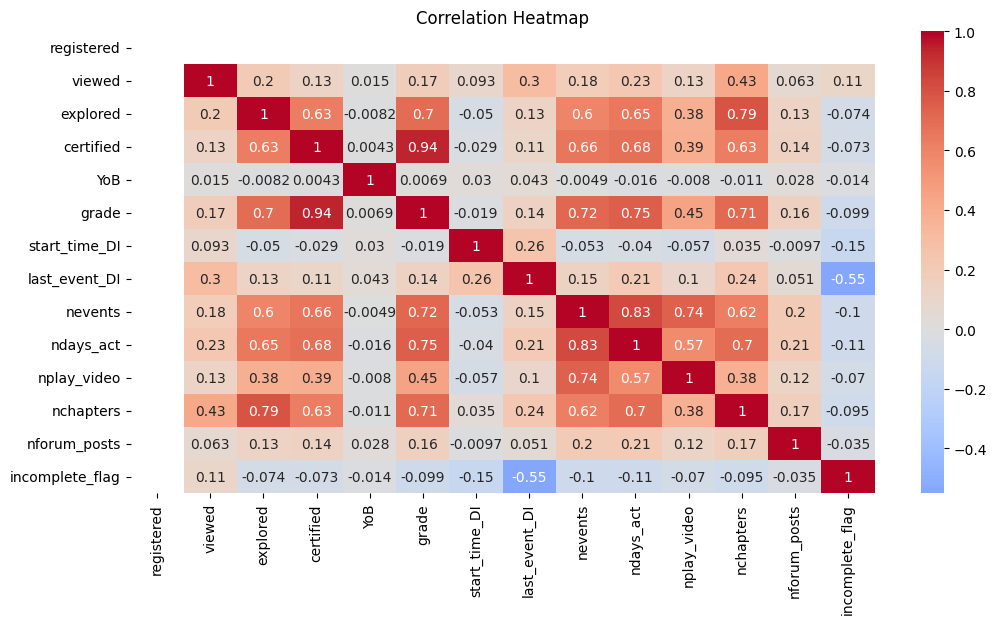

In [13]:
cols = dataset.select_dtypes(exclude=object).columns
plt.figure(figsize=(12,6))
plt.title('Correlation Heatmap')
sns.heatmap(dataset[cols].corr(), annot=True, cmap='coolwarm', center=0)